In [51]:
import sys, os
from pathlib import Path
work_dir = os.getcwd()
proj_dir = str(Path(work_dir).resolve().parents[0])
sys.path.append(proj_dir)
import time
import sympy as sp
import torch

from bc_learn.Config import Config
from bc_learn.Draw import Draw
from bc_learn.Finetuning import Finetuner
from bc_learn.Generate_data import Data
# from bc_learn.Net_pre import Net, Learner
from bc_learn.Net import Learner
from verify.kvh_verify import KVH


def print_success():
    heart = """
          *****         *****
       ***********   *************
     *************** ***************
    *********************************
     *******************************
      ****** SUCCESS SUCCESS ******
       ***************************
         ************************
           *********************
             *****************
               *************
                 *********
                   *****
                     *
    """

    print(heart)

In [52]:
import numpy as np

seed = 2025
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)

In [53]:
from rl_train.Examples import get_example_by_id, get_example_by_name, Example, Zones
class F:
    @staticmethod
    def f1(x): #(1 / (1 + np.sin(x)**2)) 0.00162777504080
        return 0.0768 *x**4  - 0.3808 *x**2  + 0.9280
    @staticmethod
    def f2(x): #(np.sin(x) / (1 + np.sin(x)**2))0.00378772829829
        return -0.1060 *x**3  + 0.6139 *x
    @staticmethod
    def f3(x): #(np.sin(x) * np.cos(x) / (1 + np.sin(x)**2))0.00140085561943
        return 0.0663 *x**5  - 0.4553 *x**3  + 0.6998 *x
    @staticmethod
    def f4(x): #(np.cos(x) / (1 + np.sin(x)**2))0.00342303163390
        return 0.0915 *x**4  - 0.6153 *x**2  + 0.8964
train_ex = Example(
        n_obs=2,
        u_dim=1,
        D_zones=Zones('box', low=[-1] * 2, up=[1] * 2),
        I_zones=Zones('box', low=[-1] * 2, up=[-0.5] * 2),
        U_zones=Zones('box', low=[0.2] * 2,up=[1] * 2),
        f=[
            lambda x, u: x[1],                          # ẋ₁ = α̇ = x[1]
            lambda x, u: -10*(-0.1576*x[0]**3  + 0.9981*x[0]) - 0.1*x[1] + u[0]  # ẋ₂ = α̈ = -g/l*sin(α) - d/(ml²)*α̇ + u/(ml²)
        ],
        u=3,
        dense=5,
        units=30,
        dt=0.01,
        max_episode=1500,
        goal='avoid',
        name='nonpoly2-pendulum'    
    )

# 转换例子

eps = 0.0024
kvh_ex = Example(
        n_obs=2+1,
        u_dim=1,
        D_zones=Zones('box', low=[-1] * 2 + [-eps], up=[1] * 2+ [eps]),
        I_zones=Zones('box', low=[-1] * 2+ [-eps], up=[-0.5] * 2+ [eps]),
        U_zones=Zones('box', low=[0.2] * 2+ [-eps],up=[1] * 2+ [eps]),
        f=[
            lambda x, u: x[1],                          # ẋ₁ = α̇ = x[1]
            lambda x, u: -10*(-0.1576*x[0]**3  + 0.9981*x[0]) - 0.1*x[1] + u[0],  # ẋ₂ = α̈ = -g/l*sin(α) - d/(ml²)*α̇ + u/(ml²)
            lambda x, u: 0.0
        ],
        u=3,
        dense=5,
        units=30,
        dt=0.01,
        max_episode=1500,
        goal='avoid',
        name='nonpoly2-pendulum'    
    )

with open(f'{proj_dir}/controller/{train_ex.name}.txt', 'r', encoding='utf-8') as f:
    controller = f.readline()
print(controller)

1.78614906114396*x1**2 - 0.239242456515708*x1*x2 + 2.75000045137824*x1 - 0.202330468057412*x2**2 - 0.332550120442973*x2


In [54]:
opts = {
    'example': train_ex,
    'lr': 0.04,
    'batch_size': 500,
    'margin': 2,
    'hidden_neurons': [10],
    'activation': ['SKIP']
}
config = Config(**opts)

epoch = 5
l = 9
config_fine = (100, 10, 0.1, 500, 1)
adaptive_margin=False

learner = Learner(config)
opt = torch.optim.AdamW(learner.net.parameters(), lr=config.lr)
data = Data(config, controller)


Initialization completed!
Controller for epoch 1:1.78614906114396*x1**2 - 0.239242456515708*x1*x2 + 2.75000045137824*x1 - 0.202330468057412*x2**2 - 0.332550120442973*x2
---------------------------------------
Start training--epoch 1
---------------------------------------
Init samples: 500 Unsafe samples: 500 Lie samples 500
10 - loss: 2.919241428375244 - accuracy init: 0.0 accuracy unsafe: 72.0 - accuracy Lie: 53.8
20 - loss: 1.4294195175170898 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 68.8
30 - loss: 1.4143515825271606 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 75.2
40 - loss: 1.2507649660110474 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 73.4
50 - loss: 1.2020758390426636 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 71.0
60 - loss: 1.1776762008666992 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 70.4
70 - loss: 1.163133978843689 - accuracy init: 100.0 accuracy unsafe: 100.0 - accuracy Lie: 73.0

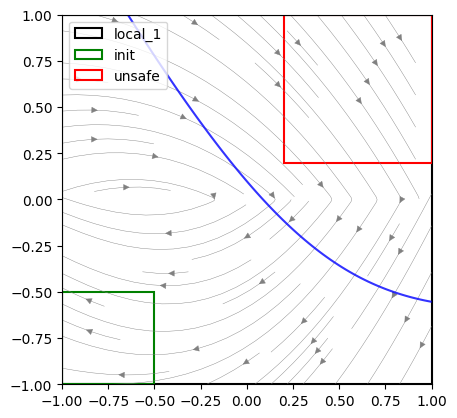

In [55]:

kvh = KVH(kvh_ex, kvh_ex.n_obs, l)
kvh.pos, vis = 1, False

t_learn, t_kvh, t_finetune = 0, 0, 0

for i in range(epoch):
    if adaptive_margin:
        config.margin = config.margin * 2
    print(f'Controller for epoch {i + 1}:{controller}')
    init, unsafe, domain, domain_dot = data.generate_data()
    t1 = time.time()
    print(f'---------------------------------------\nStart training--epoch {i + 1}\n'
            '---------------------------------------')
    learner.learn(opt, (init, unsafe, domain), domain_dot)

    t2 = time.time()
    t_learn += t2 - t1

    bc = learner.net.get_barrier()
    # print('bc:', bc)
    multiplier = learner.net.get_mul()
    # print('multiplier', multiplier)
    kvh.update_barrier(bc, multiplier, sp.sympify(controller))

    t3 = time.time()

    state = kvh.verify_all()

    t4 = time.time()
    t_kvh += t4 - t3
    if state:
        vis = True
        print_success()
        print(f'In the {i + 1} epoch, barrier certificate verification successful!')
        print(f'Barrier certificate:{bc}')
        print(f'Controller:{controller}')
        print(f'The time of learn:{t_learn}s')
        print(f'The time of verify:{t_kvh}s')
        print(f'The time of finetune:{t_finetune}s')
        if config.example.n_obs == 2:
            draw = Draw(config.example, bc, controller)
            draw.draw()
        break

    if vis:
        break

    print(f'Epoch {i + 1} failed verification barrier certificate:{bc}')
    print(f'---------------------------------------\nStart fine tuning--epoch {i + 1}\n'
            '---------------------------------------')

    finetuner = Finetuner(bc, config.example, controller, kvh, multiplier, config.device)

    t5 = time.time()

    finetuner.learn(*config_fine)

    t6 = time.time()
    t_finetune += t6 - t5
    controller, multiplier = finetuner.net.get_controller(config.example.n_obs)
    # print('controller:', controller)
    kvh.update_barrier(bc, multiplier, sp.sympify(controller))

    t3 = time.time()

    result = kvh.verify_all()

    t4 = time.time()
    t_kvh += t4 - t3
    if result:
        vis = True
        print_success()
        print(f'In the {i + 1} epoch, after the fine-tuning, barrier certificate verification successful!')
        print(f'Barrier certificate:{bc}')
        print(f'Controller:{controller}')
        print(f'The time of learn:{t_learn}s')
        print(f'The time of verify:{t_kvh}s')
        print(f'The time of finetune:{t_finetune}s')
        if config.example.n_obs == 2:
            draw = Draw(config.example, bc, controller)
            draw.draw()
        break
    else:
        data.update(controller)

if not vis:
    print('No barrier certificate found!')
